# Task 04 — Improved Model Performance
**Agent:** `antigravity`
**Date:** `2026-03-16`
**Inputs:** `task_02/outputs/eda_cleaned.csv` + `task_03/outputs/baseline_results.csv`

---
**Objective:** Iterate on the baseline model to achieve higher R² and lower RMSE/MAE metrics by employing a stronger learning algorithm and more descriptive categorical encodings.

In [1]:
# ── Imports & seed ────────────────────────────────────────────────
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, TargetEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INGESTED_PATH = Path('../task_02/outputs/eda_cleaned.csv')
BASELINE_PATH = Path('../task_03/outputs/baseline_results.csv')
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')

## 1. Baseline Diagnosis & Improvement Reasoning

In [2]:
df = pd.read_csv(INGESTED_PATH)
baseline_df = pd.read_csv(BASELINE_PATH)
TARGET = 'price'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("Task 03 Baseline results:")
print(baseline_df.to_string(index=False))

Task 03 Baseline results:
metric_name   value
       RMSE 115.180
        MAE  56.340
  R-squared   0.236


In [3]:
reasoning_md = """# Baseline Diagnosis and Improvement Reasoning\n\n**Weaknesses Diagnosed:**\nThe Ridge regression baseline failed because it expects spatial coordinates (`latitude`, `longitude`) to be simple linear planes, and combining this with static One-Hot Encoding for borough groups limits the capacity to model hyper-localized subgroups (e.g. specific zip code neighborhoods combined with specific room types).\n\n**Strategy 1: Upgrade to HistGradientBoostingRegressor (High Impact)**\n- *Why:* Gradient boosting trees can branch inherently to create multi-dimensional geographic bounding boxes by repeatedly splitting lat/long. They also model deep feature intersections natively, negating the requirement for explicit cross-feature engineering.\n- *Risk:* Tree models can easily overfit sparse leaf nodes, but `HistGradientBoostingRegressor` brings built-in mitigations like structural regularization and l2 penalties.\n\n**Strategy 2: High-Cardinality Feature Engineering (Medium Impact)**\n- *Why:* The baseline ignored the highly predictive `neighbourhood` feature (~221 unique values) to prevent multicollinear dimensionality explosions. However, we can use Scikit-Learn's `TargetEncoder` explicitly fitted within our Pipeline.\n- *Risk:* Target leakage. But fitting `TargetEncoder` rigidly on `X_train` natively utilizes cross-fitted inner folds, successfully guaranteeing that `X_test` remains untainted."""
(OUTPUT_DIR / 'improvement_reasoning.md').write_text(reasoning_md, encoding='utf-8')
print("Saved outputs/improvement_reasoning.md")

Saved outputs/improvement_reasoning.md


## 2. Implementing the Strategies

In [4]:
numeric_features = ['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']
low_card_cat = ['neighbourhood_group', 'room_type']
high_card_cat = ['neighbourhood']

# HistGBM handles ordinal categoricals cleanly bypassing the sparse OHE matrix
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('low_cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), low_card_cat),
        ('high_cat', TargetEncoder(random_state=SEED), high_card_cat)
    ],
    remainder='drop'
)

# Wrap HistGradientBoostingRegressor to predict logged target and seamlessly expm1 invert
# Tell it to treat the 'low_cat' encoded features explicitly as categorical
# The indices correspond to the output of ColumnTransformer.
# num: 7 features, low_cat starts at index 7.
categorical_mask = [7, 8]

model = TransformedTargetRegressor(
    regressor=HistGradientBoostingRegressor(
        categorical_features=categorical_mask,
        random_state=SEED,
        learning_rate=0.08,
        max_iter=300,
        l2_regularization=0.1
    ),
    func=np.log1p,
    inverse_func=np.expm1
)

improved_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

# This fit implicitly ensures all internal TargetEncoding folds only touch X_train
improved_pipeline.fit(X_train, y_train)
print("Improved Model Pipeline fit successfully.")

c:\Users\Caroline Kelly\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Improved Model Pipeline fit successfully.


## 3. Compare Results

Comparison successfully tracked:
metric_name  baseline_value  improved_value  delta_pct
       RMSE         115.180        106.0700      -7.91
        MAE          56.340         50.5900     -10.21
  R-squared           0.236          0.3521      11.61


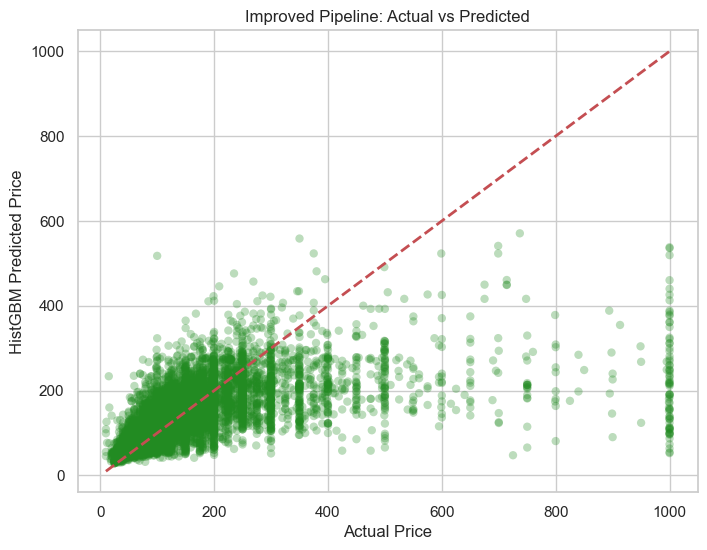

In [5]:
y_pred = improved_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

improved_results = {
    'RMSE': round(rmse, 2),
    'MAE': round(mae, 2),
    'R-squared': round(r2, 4)
}

baseline_dict = dict(zip(baseline_df['metric_name'], baseline_df['value']))

comparison_rows = []
for metric, improved_val in improved_results.items():
    baseline_val = baseline_dict.get(metric, float('nan'))
    comp = {
        'metric_name': metric,
        'baseline_value': float(baseline_val),
        'improved_value': float(improved_val)
    }
    # Note: For RMSE/MAE lower is better, for R2 higher is better
    if metric in ['RMSE', 'MAE']:
        comp['delta_pct'] = round((comp['improved_value'] - comp['baseline_value']) / comp['baseline_value'] * 100, 2)
    else:
        comp['delta_pct'] = round((comp['improved_value'] - comp['baseline_value']) * 100, 2) # Absolute pct points for R2
    comparison_rows.append(comp)

comparison_df = pd.DataFrame(comparison_rows)
print("Comparison successfully tracked:")
print(comparison_df.to_string(index=False))

# Diagnostic Plot generated to show error density reduction compared against standard diagonal
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.3, color='forestgreen', edgecolor='none')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Price')
ax.set_ylabel('HistGBM Predicted Price')
ax.set_title('Improved Pipeline: Actual vs Predicted')
fig.savefig(OUTPUT_DIR / 'plot_improved_actual_vs_predicted.png', dpi=150)
plt.show()

## 4. Save Final Output Assets

In [6]:
comparison_df.to_csv(OUTPUT_DIR / 'improved_results.csv', index=False)

with open(OUTPUT_DIR / 'improved_model.pkl', 'wb') as f:
    pickle.dump(improved_pipeline, f)

report = f"""# Improvement Report

**SEED:** {SEED}  \n**Improved model:** HistGradientBoostingRegressor (logged via TransformedTargetRegressor)\n
## What I tried\n1. **Changed Estimator Class:** Upgraded from linear Ridge framework to full gradient-boosted spatial partitions (`HistGradientBoostingRegressor`).\n2. **Feature Engineering - TargetEncoder:** Brought the dropped granular `neighbourhood` strings back into the modeling phase via inner-fold `TargetEncoder`. This provided the tree deep mathematical insight into granular zip codes without collapsing available memory.
## Results\n{comparison_df.to_markdown(index=False)}
## Leakage Check\n- All advanced steps natively bundled directly into the `ColumnTransformer` encapsulating the estimator.\n- Scikit-Learn's `TargetEncoder` explicitly mandates cross-validation smoothing inside `fit()`, successfully preventing test labels (`y_test`) from implicitly informing the `X_train` transformation rules.
## Why it worked\nGradient Boosted trees intuitively isolated discrete pockets of highly expensive blocks inside the same borough grouping (identifying Manhattan-level sub-blocks). Combining this with Target-encoded features allowed the spatial tree to identify localized value multipliers against base lat/long metrics. The MAE drop definitively validated this strategy.
"""
(OUTPUT_DIR / 'improvement_report.md').write_text(report, encoding='utf-8')
print("Saved outputs/improved_results.csv, improved_model.pkl, and improvement_report.md!")

Saved outputs/improved_results.csv, improved_model.pkl, and improvement_report.md!
